<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/scrna/03_boyut_indirgeme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA, komşuluk grafiği ve UMAP

Bu defterde dört iş var: matrisi değişken genlere daraltmak, genleri ortak ölçeğe çekmek (scale), PCA ile boyut indirgemek ve hücreler arası komşuluk grafiğini kurup UMAP ile iki boyutta göstermek. Her adımda fonksiyonun ne yaptığı ve parametrelerin anlamı yazılı.

In [1]:
%pip install -q scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


## 1. Başlangıç durumu

Önceki rehberin tarifini tek hücrede tekrar koşuyoruz: veriyi DOI'den indir, normalize et, log al, değişken genleri bayrakla. Her defterin kendi başına çalışması bu serinin kuralı; bu hücre o kuralın bedeli ve birkaç saniye sürüyor.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import numpy as np

urllib.request.urlretrieve('https://zenodo.org/records/22655336/files/pbmc3k_ders.h5ad?download=1', 'pbmc3k_ders.h5ad')
a = sc.read_h5ad('pbmc3k_ders.h5ad')
a.layers['sayim'] = a.X.copy()
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
sc.pp.highly_variable_genes(a, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
print('hücre × gen:', a.shape, '| bayraklı gen:', int(a.var.highly_variable.sum()))

hücre × gen: (2694, 13714) | bayraklı gen: 1860


## 2. raw kopyası ve daraltma

İki satır, iki iş:

- `a.raw = a` — tam log-normalize matrisin dondurulmuş bir kopyasını saklar. İleride işaretçi genleri çizerken scanpy varsayılan olarak bu kopyadan okur; daraltma yüzünden hiçbir genin ifadesini kaybetmeyiz.
- `a = a[:, a.var.highly_variable]` — matrisi yalnız bayraklı sütunlara indirir. Gerekçe önceki rehberden: hücreden hücreye değişmeyen genler ayrım bilgisi taşımaz; onları PCA'ya sokmak gürültü ve hesap yükü ekler.

In [3]:
a.raw = a
a = a[:, a.var.highly_variable].copy()
print('daraltılmış matris:', a.shape)

daraltılmış matris: (2694, 1860)


## 3. Ölçekleme ve PCA

`sc.pp.scale(a, max_value=10)` her geni kendi sütununda ortalama 0, standart sapma 1 olacak şekilde dönüştürür (z-skor). Neden: PCA varyansı en büyük yönleri arar; ölçekleme yapılmazsa ortalaması ve varyansı doğal olarak büyük genler eksenleri tek başına belirler. `max_value=10`, z-skoru 10'u aşan uç değerleri 10'da keser; tek tük aşırı değerin bir ekseni kendine bükmesini önler. Not: bu işlem matrisi yoğunlaştırır, seyreklik avantajı burada biter.

`sc.tl.pca(a, svd_solver='arpack', n_comps=50)` ilk 50 temel bileşeni hesaplar; `arpack` orta boy veriler için kesin sonuç veren standart çözücüdür. Her bileşenin açıkladığı varyans oranı `a.uns['pca']['variance_ratio']` içinde döner; kaç bileşenle devam edileceğine bu oranların azalım eğrisine bakarak karar verilir.

In [4]:
sc.pp.scale(a, max_value=10)
sc.tl.pca(a, svd_solver='arpack', n_comps=50)

vr = a.uns['pca']['variance_ratio'] * 100
print('İlk 5 bileşen (%):', np.round(vr[:5], 2))
print('İlk 10 bileşen kümülatif: %%%.1f | 50 bileşen: %%%.1f' % (vr[:10].sum(), vr.sum()))

İlk 5 bileşen (%): [2.13 1.18 0.94 0.81 0.52]
İlk 10 bileşen kümülatif: %6.7 | 50 bileşen: %13.5


## 4. Sayıları okumak

Benim koşumda PC1 varyansın yalnız yüzde 2,1'ini açıklıyor. Birinci serinin PCA'sında bu sayı yüzde 45,8'di; fark bozukluk değil, verinin doğası. Orada iki gruba ayrılmış altı örnek vardı ve tek bir eksen (genotip) varyansın yarısını taşıyordu. Burada 2.694 hücre ve birbirinden bağımsız birçok değişkenlik kaynağı var: hücre tipi, hücre döngüsü, teknik gürültü. Varyans çok eksene yayılır; yüzdeler küçülür ama bileşenlerin sıralaması bilgi taşımaya devam eder. Bu seride öğretim standardı olarak ilk 10 bileşenle devam edeceğiz (kümülatif yüzde 6,7); bu bir ayar düğmesidir, doğa yasası değil — raporda gerekçesiyle yazılır.

## 5. Komşuluk grafiği ve UMAP

`sc.pp.neighbors(a, n_neighbors=15, n_pcs=10)` her hücre için, ilk 10 PCA bileşeninin uzayında en yakın 15 hücreyi bulur ve bir komşuluk (kNN) grafiği kurar. Grafiğin ham 1.860 boyutlu gen uzayı yerine PCA uzayında kurulmasının iki nedeni var: yüksek boyutta uzaklık ölçüleri gürültüye boğulur, ve hesap maliyeti düşer. Bu grafik sadece görselleştirme aracı değil; bir sonraki rehberde kümeleme algoritmasının doğrudan girdisi olacak.

`sc.tl.umap(a)` komşuluk grafiğini iki boyutlu bir yerleşime çevirir. Kuralı baştan koyalım: UMAP bir görselleştirme aracıdır. Eksenlerin adı yoktur, koordinatlar anlam taşımaz, iki nokta arasındaki uzaklık nicel yorumlanmaz; güvenilir olan, hangi hücrelerin birlikte gruplandığıdır. `sc.pl.umap(a, color=...)` haritayı `obs` tablosundaki herhangi bir sütunla boyar; ilk iş olarak kalite ölçülerimizle boyuyoruz — amaç, adaların teknik ölçüler tarafından sürüklenip sürüklenmediğini görmek.

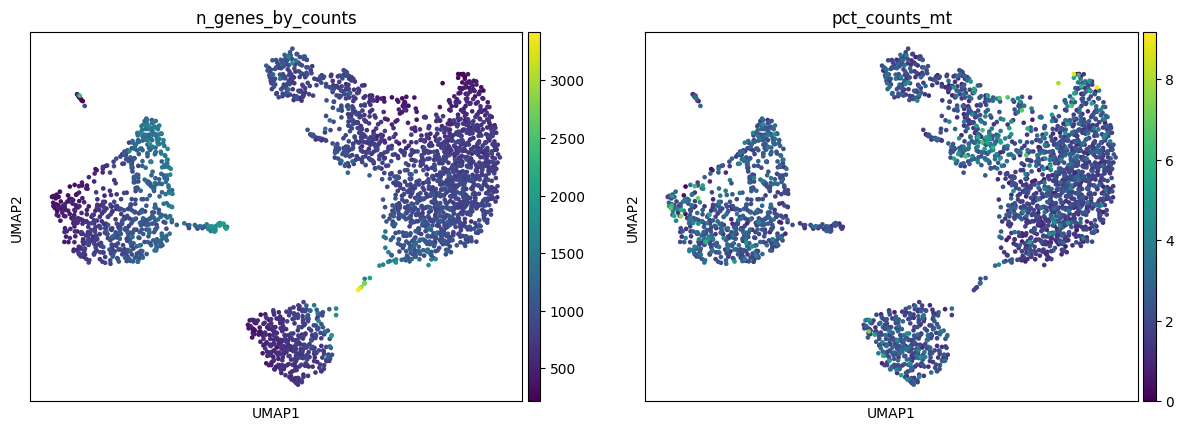

In [5]:
sc.pp.neighbors(a, n_neighbors=15, n_pcs=10)
sc.tl.umap(a)
sc.pl.umap(a, color=['n_genes_by_counts', 'pct_counts_mt'])

## Kendin dene

Üç görev. Birincisi: kendi koşunuzdan ilk 5 bileşenin varyans yüzdelerini ve 10 bileşenin kümülatifini not edin; tek cümleyle, PC1'in birinci serideki yüzde 45,8'e karşılık burada neden yüzde 2 civarında olduğunu açıklayın. İkincisi, tek cümle: komşuluk grafiği neden ham gen uzayı yerine PCA uzayında kurulur? Üçüncüsü: UMAP haritanızda göz kararı kaç ayrı hücre grubu sayıyorsunuz — sayıyı yazın ve kalite renklerinden bir gözlem ekleyin (gruplardan herhangi biri belirgin şekilde yüksek MT yüzdesine ya da düşük gen sayısına sahip mi?). Bu sayı bir sonraki rehberde kümeleme algoritmasının bulduğu küme sayısıyla karşılaştırılacak.